# Notebook 04 – Decision Tree

## Objectif

Après avoir préparé les données dans le Notebook 03 et utilisé la Régression Logistique comme modèle de référence, cette étape consiste à construire un arbre de décision afin de prédire la probabilité qu'un contrat d'assurance automobile déclare au moins un sinistre.

L'objectif est également de visualiser le fonctionnement de l'arbre, d'analyser les variables les plus importantes et d'optimiser ses paramètres pour améliorer ses performances.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

pd.set_option("display.max_columns", None)

In [2]:
data = pd.read_csv("../data/processed/insurance_clean.csv")

In [3]:
print(data.shape)
data.head()

(678013, 14)


,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,ClaimAmountTotal,HasClaim
0,1,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,1
1,3,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,1
2,5,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie,0.0,1
3,10,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,1
4,11,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,1


In [4]:
features = [
    "Exposure",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    "VehBrand",
    "VehGas",
    "Area",
    "Density",
    "Region"
]

X = data[features]
y = data["HasClaim"]

In [5]:
print("X :", X.shape)
print("y :", y.shape)

X : (678013, 10)
y : (678013,)


In [6]:
numeric_features = [
    "Exposure",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    "Density"
]

categorical_features = [
    "VehBrand",
    "VehGas",
    "Area",
    "Region"
]

In [7]:
print("Numériques :", numeric_features)
print("Catégorielles :", categorical_features)

Numériques : ['Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density']
Catégorielles : ['VehBrand', 'VehGas', 'Area', 'Region']


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (542410, 10)
X_test : (135603, 10)
y_train : (542410,)
y_test : (135603,)


In [11]:
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [12]:
tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Exposure','VehPower','VehAge',...,'Area','Density','Region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatw

In [13]:
y_pred_tree = tree_pipeline.predict(X_test)
y_proba_tree = tree_pipeline.predict_proba(X_test)[:, 1]

In [14]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_tree), 4))
print("\nClassification Report :")
print(classification_report(y_test, y_pred_tree))

cm = confusion_matrix(y_test, y_pred_tree)
print("\nMatrice de confusion :")
print(cm)

roc = roc_auc_score(y_test, y_proba_tree)
print("\nROC-AUC :", round(roc, 4))

Accuracy : 0.9013

Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.94      0.95    128791
           1       0.10      0.12      0.11      6812

    accuracy                           0.90    135603
   macro avg       0.53      0.53      0.53    135603
weighted avg       0.91      0.90      0.91    135603


Matrice de confusion :
[[121380   7411]
 [  5968    844]]

ROC-AUC : 0.5329


Un premier arbre de décision a été entraîné sans réglage particulier afin de servir de modèle de référence. Les résultats montrent une accuracy de 90,13 %, mais un rappel de seulement 12 % pour les contrats sinistrés. La matrice de confusion indique que le modèle détecte 844 sinistres tout en laissant passer 5 968 contrats risqués. Le score ROC-AUC de 0,533 montre que ce premier arbre possède une capacité de discrimination limitée. Ces résultats justifient l'étape suivante, qui consiste à optimiser les paramètres de l'arbre afin d'améliorer ses performances.

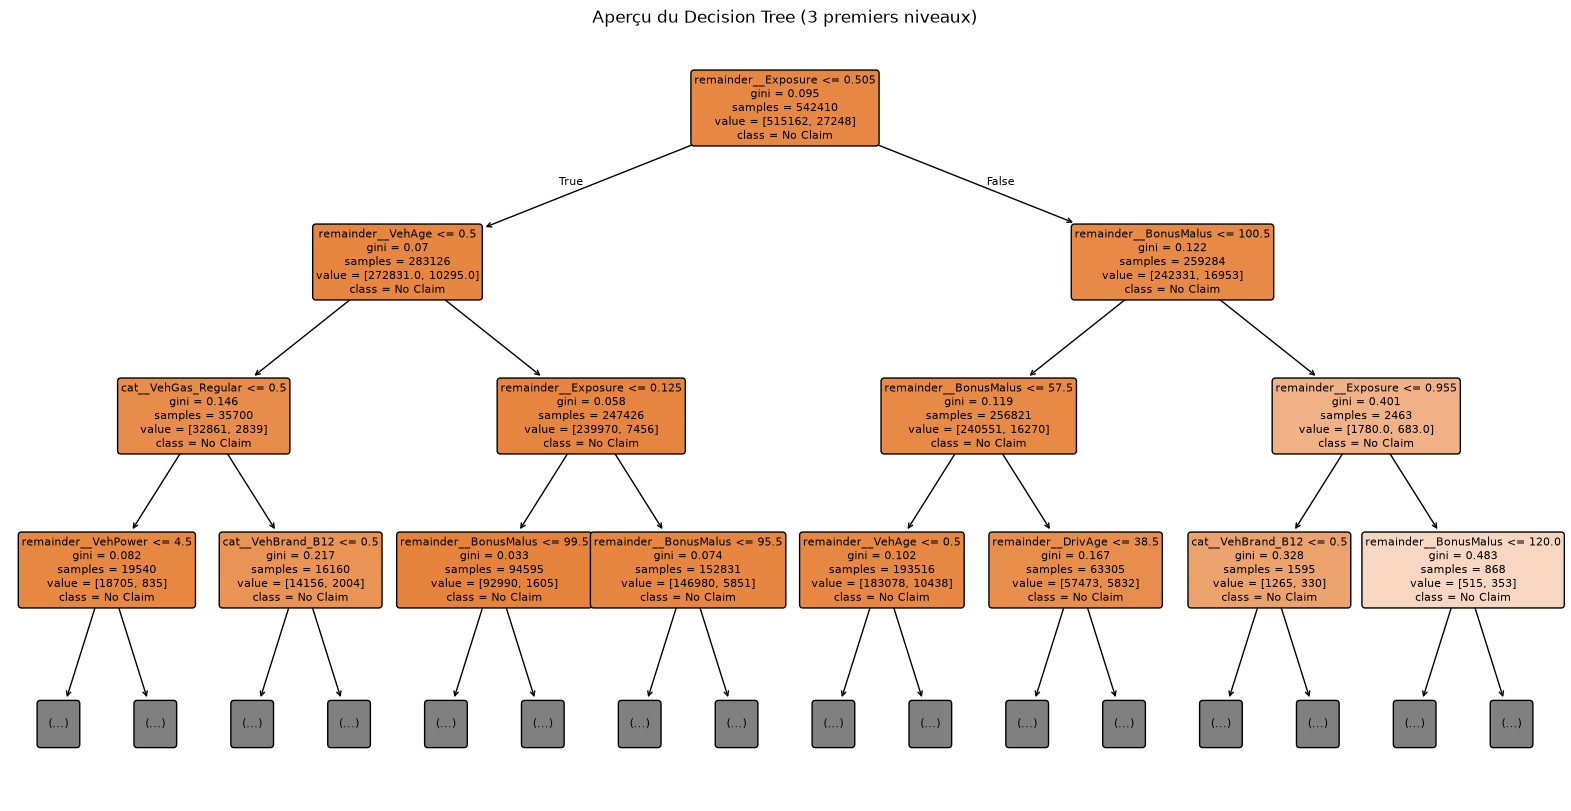

In [15]:
plt.figure(figsize=(20,10))

plot_tree(
    tree_pipeline.named_steps["model"],
    feature_names=tree_pipeline.named_steps["preprocessor"].get_feature_names_out(),
    class_names=["No Claim", "Claim"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Aperçu du Decision Tree (3 premiers niveaux)")
plt.show()

Créer le nouvel arbre

In [16]:
tree_pipeline_optimized = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=50,
        min_samples_split=100,
        random_state=42
    ))
])

In [17]:
tree_pipeline_optimized.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Exposure','VehPower','VehAge',...,'Area','Density','Region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatw

In [18]:
y_pred_tree_opt = tree_pipeline_optimized.predict(X_test)
y_proba_tree_opt = tree_pipeline_optimized.predict_proba(X_test)[:, 1]

In [19]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_tree_opt), 4))

print("\nClassification Report :")
print(classification_report(y_test, y_pred_tree_opt))

cm = confusion_matrix(y_test, y_pred_tree_opt)

print("\nMatrice de confusion :")
print(cm)

roc = roc_auc_score(y_test, y_proba_tree_opt)

print("\nROC-AUC :", round(roc, 4))

Accuracy : 0.9497

Classification Report :
              precision    recall  f1-score   support

           0       0.95      1.00      0.97    128791
           1       0.42      0.00      0.01      6812

    accuracy                           0.95    135603
   macro avg       0.68      0.50      0.49    135603
weighted avg       0.92      0.95      0.93    135603


Matrice de confusion :
[[128763     28]
 [  6792     20]]

ROC-AUC : 0.6848


L'arbre de décision a été optimisé en limitant sa profondeur (max_depth=8) et en imposant un nombre minimal d'observations dans chaque feuille (min_samples_leaf=50) ainsi qu'avant chaque séparation (min_samples_split=100). Cette optimisation a permis d'améliorer la capacité de discrimination du modèle, avec un ROC-AUC passant de 0,533 à 0,685, tout en réduisant considérablement le temps d'entraînement. En revanche, le modèle reste fortement influencé par le déséquilibre des classes et détecte très peu de contrats sinistrés (20 sur 6 812), ce qui montre que l'Accuracy seule ne constitue pas un indicateur suffisant pour évaluer un modèle d'assurance.

In [20]:
# Importance des variables
importances = tree_pipeline_optimized.named_steps["model"].feature_importances_

# Noms des variables après le prétraitement
feature_names = tree_pipeline_optimized.named_steps["preprocessor"].get_feature_names_out()

# Tableau trié
importance_df = (
    pd.DataFrame({
        "Variable": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

importance_df.head(10)

,Variable,Importance
44,remainder__BonusMalus,0.276634
40,remainder__Exposure,0.211792
41,remainder__VehPower,0.120702
42,remainder__VehAge,0.119995
3,cat__VehBrand_B12,0.089077
43,remainder__DrivAge,0.082613
12,cat__VehGas_Regular,0.059270
45,remainder__Density,0.018578
11,cat__VehGas_Diesel,0.012068
25,cat__Region_Centre,0.001967


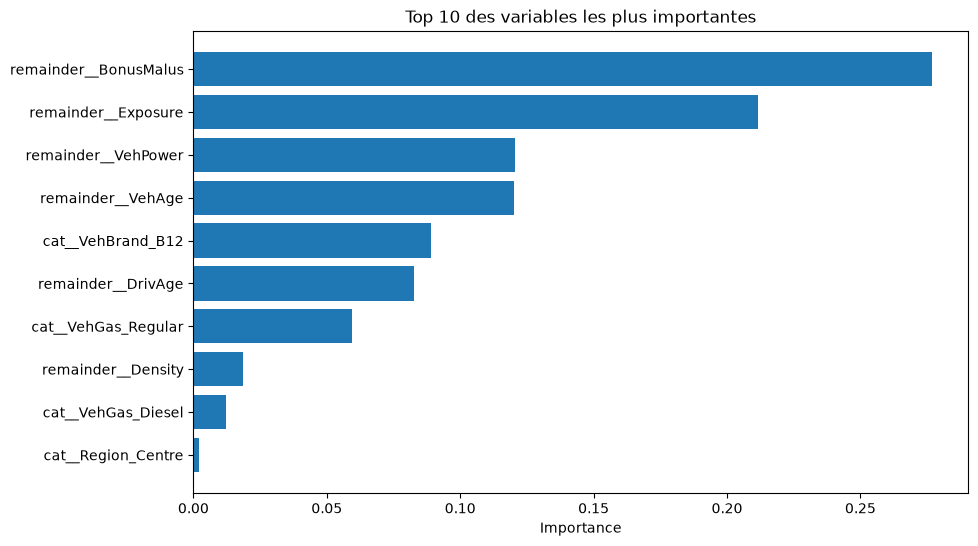

In [21]:
plt.figure(figsize=(10,6))

top10 = importance_df.head(10)

plt.barh(top10["Variable"][::-1], top10["Importance"][::-1])

plt.title("Top 10 des variables les plus importantes")
plt.xlabel("Importance")

plt.show()

L'analyse de l'importance des variables montre que le Bonus-Malus est le facteur le plus déterminant dans les décisions de l'arbre, suivi par l'exposition du contrat, la puissance et l'âge du véhicule. Ces résultats sont cohérents avec le domaine de l'assurance automobile, où l'historique du conducteur et les caractéristiques du véhicule influencent directement le niveau de risque.

## Comparaison des modèles

Avant de passer au modèle Random Forest, nous comparons les performances des différents modèles testés jusqu'à présent.

In [22]:
comparison = pd.DataFrame({
    "Modèle": [
        "Logistic Regression",
        "Logistic Balanced",
        "Decision Tree",
        "Decision Tree Optimisé"
    ],
    "Accuracy": [
        0.9498,
        0.5813,
        0.9013,
        0.9497
    ],
    "Recall": [
        0.0006,   # environ 4/6812
        0.611,
        0.124,
        0.003
    ],
    "ROC-AUC": [
        0.6384,
        0.6389,
        0.5329,
        0.6848
    ]
})

comparison

,Modèle,Accuracy,Recall,ROC-AUC
0,Logistic Regression,0.9498,0.0006,0.6384
1,Logistic Balanced,0.5813,0.6110,0.6389
2,Decision Tree,0.9013,0.1240,0.5329
3,Decision Tree Optimisé,0.9497,0.0030,0.6848


## Conclusion

Le modèle Decision Tree a été étudié sous deux versions : une version simple et une version optimisée.

L'optimisation des paramètres (`max_depth`, `min_samples_leaf` et `min_samples_split`) a permis de simplifier l'arbre, de réduire le temps d'entraînement et d'améliorer la capacité de discrimination du modèle (ROC-AUC = 0,6848).

L'analyse des importances des variables montre que le Bonus-Malus, l'Exposure, la puissance du véhicule et l'âge du véhicule sont les facteurs les plus influents dans les décisions de l'arbre.

Cependant, malgré une excellente Accuracy, le rappel de la classe des contrats sinistrés reste très faible. Cette limite justifie l'utilisation d'un modèle plus robuste : le Random Forest.

Trouver un contrat prédit Claim

In [23]:
# Trouver le premier contrat prédit comme Claim (1)
claim_index = np.where(y_pred_tree_opt == 1)[0][0]

print("Position dans X_test :", claim_index)

Position dans X_test : 4426


In [24]:
client = X_test.iloc[claim_index]

print("Informations du contrat :")
display(client.to_frame().T)

Informations du contrat :


,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
430872,1.0,7,13,25,147,B1,Regular,D,1541,Languedoc-Roussillon


In [25]:
proba = tree_pipeline_optimized.predict_proba(X_test.iloc[[claim_index]])[0]

print(f"Probabilité No Claim : {proba[0]:.2%}")
print(f"Probabilité Claim    : {proba[1]:.2%}")

Probabilité No Claim : 32.26%
Probabilité Claim    : 67.74%


In [26]:
from sklearn.tree import _tree

# Récupérer les objets du pipeline
preprocessor = tree_pipeline_optimized.named_steps["preprocessor"]
tree = tree_pipeline_optimized.named_steps["model"]

# Transformer le client comme le fait le pipeline
client_transformed = preprocessor.transform(X_test.iloc[[claim_index]])

# Chemin dans l'arbre
node_indicator = tree.decision_path(client_transformed)
leaf_id = tree.apply(client_transformed)

feature_names = preprocessor.get_feature_names_out()

print("Chemin suivi par le contrat :\n")

for node_id in node_indicator.indices:
    if leaf_id[0] == node_id:
        print(f"➡ Feuille finale (nœud {node_id})")
        print("Décision :", "Claim" if tree.tree_.value[node_id][0][1] > tree.tree_.value[node_id][0][0] else "No Claim")
        print("value =", tree.tree_.value[node_id][0])
        break

    feature = feature_names[tree.tree_.feature[node_id]]
    threshold = tree.tree_.threshold[node_id]
    value = client_transformed[0, tree.tree_.feature[node_id]]

    direction = "Oui (gauche)" if value <= threshold else "Non (droite)"

    print(f"{feature} <= {threshold:.2f} ?")
    print(f"Valeur du client : {value:.2f} → {direction}\n")

Chemin suivi par le contrat :

remainder__Exposure <= 0.50 ?
Valeur du client : 1.00 → Non (droite)

remainder__BonusMalus <= 100.50 ?
Valeur du client : 147.00 → Non (droite)

remainder__Exposure <= 0.95 ?
Valeur du client : 1.00 → Non (droite)

remainder__BonusMalus <= 120.00 ?
Valeur du client : 147.00 → Non (droite)

remainder__Density <= 927.50 ?
Valeur du client : 1541.00 → Non (droite)

➡ Feuille finale (nœud 420)
Décision : Claim
value = [0.32258065 0.67741935]


Pour expliquer une prédiction, j'ai utilisé le chemin suivi dans l'arbre de décision. Dans cet exemple réel, le contrat possède une exposition annuelle complète (Exposure = 1), un Bonus-Malus élevé (147) et une densité de population importante (1541). À chaque question, le contrat suit une branche de l'arbre jusqu'à une feuille finale où environ 67,7 % des contrats similaires appartiennent à la classe Claim. Le modèle prédit donc un sinistre, ce qui montre que l'arbre fournit une décision interprétable et traçable.